# Summer Curriculum - Week 1

## Experiment 1 - Creating my own FFN network from scratch

the below code creates a FFN to approximate y = sin(x)

In [1]:
# Import necessary libraries
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

In [2]:
# Create data points and labels using the range of -2pi to 2pi
# this allows for a full period of the sine wave to be captured in the data
data_points = torch.linspace(-2*np.pi, 2*np.pi, 1000)
labels = torch.sin(data_points)

In [3]:
# Reshape the data points and labels to be in the correct format for the nn.Linear layer
data_points = data_points.reshape(-1, 1)
labels = labels.reshape(-1, 1)

In [4]:
# Build the loop for our model
# Start with subclassing the nn.Module class to create a custom model
class SinModel(nn.Module):
    def __init__(self):
        super().__init__()            # Initialize the parent class
        self.layers = nn.Sequential(  # Chain the layers in a sequential order
            nn.Linear(1, 32),         # 1 input feature, 32 hidden units
            nn.ReLU(),                # non-linearity to introduce non-linear relationships
            nn.Linear(32, 32),        # 32 hidden units goes to another layer of 32 hidden units
            nn.ReLU(),                # non-linearity again
            nn.Linear(32, 1)          # final layer outputs a single value (the prediction)
        )
    def forward(self, x):
        return self.layers(x)

In [5]:
# Choose the device to run the model on
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

data_points = data_points.to(device)
labels = labels.to(device)
model = SinModel().to(device)

Using mps device


In [6]:
# Next we are going to set MSE as the loss function
criterion = nn.MSELoss()

In [7]:
# Next we are going to set up the optimizer to update the model's parameters
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

In [8]:
# =====================================================================
# PICK UP HERE TOMORROW — Step 1: Training loop
# Fill in the 5 TODO lines. The structure is the same five steps you
# talked through with Claude: forward, loss, zero_grad, backward, step.
# =====================================================================

epochs = 2000
for epoch in range(epochs):
    # (a) Forward pass — run data_points through the model to get predictions
    predictions =   model(data_points)

    # (b) Compute the loss between predictions and labels using `criterion`
    loss =   criterion(predictions, labels)

    # (c) Clear gradients accumulated from the previous step
    #     (method on `optimizer`, starts with zero_)
    optimizer.zero_grad()

    # (d) Backpropagate the loss to compute gradients w.r.t. every parameter
    #     (method on the loss tensor itself, from the autograd lesson)
    loss.backward()

    # (e) Take a step in the direction the gradients suggest
    #     (method on `optimizer`)
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


Epoch 0, Loss: 0.621685
Epoch 100, Loss: 0.360161
Epoch 200, Loss: 0.267505
Epoch 300, Loss: 0.186195
Epoch 400, Loss: 0.140853
Epoch 500, Loss: 0.123580
Epoch 600, Loss: 0.117199
Epoch 700, Loss: 0.113795
Epoch 800, Loss: 0.111160
Epoch 900, Loss: 0.108759
Epoch 1000, Loss: 0.106455
Epoch 1100, Loss: 0.104209
Epoch 1200, Loss: 0.101985
Epoch 1300, Loss: 0.099095
Epoch 1400, Loss: 0.096895
Epoch 1500, Loss: 0.094628
Epoch 1600, Loss: 0.092284
Epoch 1700, Loss: 0.089854
Epoch 1800, Loss: 0.087335
Epoch 1900, Loss: 0.084724


In [11]:
# =====================================================================
# Step 2 — Evaluation: generate predictions from the trained model.
# Hint: switch the model to eval mode, and wrap the forward pass in a
# torch.no_grad() context so PyTorch doesn't build a gradient graph
# (we're just running the model, not training it anymore).
# =====================================================================

# TODO: switch model to eval mode
model.eval()

# TODO: inside a `with torch.no_grad():` block, run a forward pass
#       over data_points and store the result as `learned_curve`
with torch.no_grad():
    learned_curve = model(data_points)

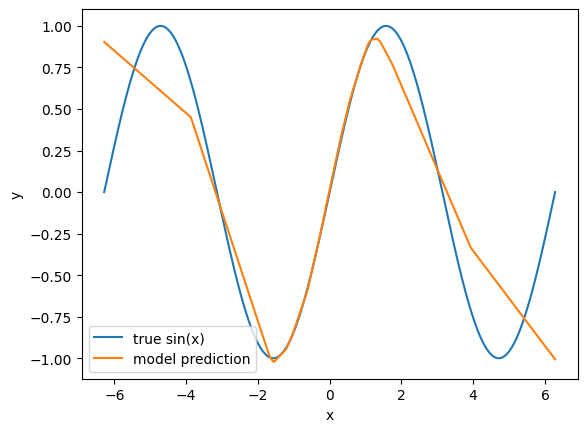

In [15]:
# =====================================================================
# Step 3 — Plot the true sine curve vs. the model's learned curve.
# Hint: matplotlib works with numpy arrays, and tensors on the MPS
# device need .cpu() before .numpy() can be called on them.
# =====================================================================

# TODO: convert data_points, labels, and learned_curve to numpy
#       (remember to call .cpu() first since they're on the MPS device)
data_points_np = data_points.cpu().numpy()
labels_np = labels.cpu().numpy()
learned_curve_np = learned_curve.cpu().numpy()
# TODO: plt.plot(x_np, true_sin_np, label="true sin(x)")
plt.plot(data_points_np, labels_np, label = "true sin(x)")
# TODO: plt.plot(x_np, learned_np,   label="model prediction")
plt.plot(data_points_np, learned_curve_np, label = "model prediction")
# TODO: plt.legend(); plt.xlabel("x"); plt.ylabel("y"); plt.show()
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()
